In [8]:
import pathlib
og_path = pathlib.Path("kagglecatsanddogs_5340\PetImages")
new_path = pathlib.Path("subset_cats_dogs")


In [ ]:
#################################debugging code (1 file was corrupted)#################################

import os
# Remove empty files
for root, dirs, files in os.walk(new_path):
    for name in files:
        path = os.path.join(root, name)
        if os.path.getsize(path) == 0:
            os.remove(path)
            print(f"Removed {path}")
#################################debugging code (1 file was corrupted)#################################


In [69]:
import os
import shutil

start_inices = [0, 1000, 1500]
end_indices = [1000, 1500, 2500]

for i, subset in enumerate(("train", "validation", "test")):
    for category in ("cat", "dog"):
        directory = new_path / subset / category
        os.makedirs(directory, exist_ok=True)
        fnames = [f"{i}.jpg" for i in range(start_inices[i], end_indices[i])]
        for fname in fnames:
            src = og_path / category / fname
            if not src.exists() or src.stat().st_size == 0:
                continue
            dst = directory / fname
            shutil.copyfile(src, dst)
    

In [70]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))                           #resize to 180x180
x = layers.Rescaling(1./255)(inputs)                                #rescale to 0-1

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)

outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_9 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_45 (Conv2D)          (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_36 (MaxPooli  (None, 89, 89, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_46 (Conv2D)          (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_37 (MaxPooli  (None, 43, 43, 64)        0         
 ng2D)                                                     

In [71]:
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [72]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(new_path / "train", image_size=(180, 180), batch_size=32)

validation_dataset = image_dataset_from_directory(new_path / "validation", image_size=(180, 180), batch_size=32)
test_dataset = image_dataset_from_directory(new_path / "test", image_size=(180, 180), batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [73]:
#################################debugging code (1 file was corrupted)#################################
#check if the data is loaded correctly
print("Training dataset:")
print(f"Number of batches: {len(train_dataset)}")
print("\nValidation dataset:")
print(f"Number of batches: {len(validation_dataset)}")
print("\nTest dataset:")
print(f"Number of batches: {len(test_dataset)}")

import tensorflow as tf
# Check the shape and content of one batch
i=0
for images, labels in train_dataset.take(37):
	print("\nShape of image batch:", images.shape)
	print("Shape of label batch:", labels.shape)
	print("Labels in this batch:", labels.numpy())
	print("Min pixel value:", tf.reduce_min(images))
	print("Max pixel value:", tf.reduce_max(images))
	print("Batch Num:", i)
	i+=1
#################################debugging code (1 file was corrupted)#################################

Training dataset:
Number of batches: 63

Validation dataset:
Number of batches: 32

Test dataset:
Number of batches: 63

Shape of image batch: (32, 180, 180, 3)
Shape of label batch: (32,)
Labels in this batch: [1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 1 0 0 1]
Min pixel value: tf.Tensor(0.0, shape=(), dtype=float32)
Max pixel value: tf.Tensor(255.0, shape=(), dtype=float32)
Batch Num: 0

Shape of image batch: (32, 180, 180, 3)
Shape of label batch: (32,)
Labels in this batch: [0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0]
Min pixel value: tf.Tensor(0.0, shape=(), dtype=float32)
Max pixel value: tf.Tensor(255.0, shape=(), dtype=float32)
Batch Num: 1

Shape of image batch: (32, 180, 180, 3)
Shape of label batch: (32,)
Labels in this batch: [0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 1]
Min pixel value: tf.Tensor(0.0, shape=(), dtype=float32)
Max pixel value: tf.Tensor(255.0, shape=(), dtype=float32)
Batch Num: 2

Shape of image batch:

In [74]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


In [77]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath="convnet_cat_dog.h5", save_best_only=True, monitor="val_loss") ]

history = model.fit(train_dataset, epochs=30, validation_data=validation_dataset, callbacks=callbacks)

Epoch 1/30


63/63 [==============================] - ETA: 0s - loss: 0.6825 - accuracy: 0.5720

c:\Users\amfer\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


63/63 [==============================] - 92s 1s/step - loss: 0.6825 - accuracy: 0.5720 - val_loss: 0.6720 - val_accuracy: 0.5570
Epoch 2/30
63/63 [==============================] - 90s 1s/step - loss: 0.6669 - accuracy: 0.6120 - val_loss: 0.6651 - val_accuracy: 0.6150
Epoch 3/30
63/63 [==============================] - 83s 1s/step - loss: 0.6295 - accuracy: 0.6545 - val_loss: 0.6322 - val_accuracy: 0.6470
Epoch 4/30
63/63 [==============================] - 85s 1s/step - loss: 0.6020 - accuracy: 0.6750 - val_loss: 0.6049 - val_accuracy: 0.6620
Epoch 5/30
63/63 [==============================] - 80s 1s/step - loss: 0.5679 - accuracy: 0.7030 - val_loss: 0.6321 - val_accuracy: 0.6400
Epoch 6/30
63/63 [==============================] - 83s 1s/step - loss: 0.5430 - accuracy: 0.7235 - val_loss: 0.5991 - val_accuracy: 0.6740
Epoch 7/30
63/63 [==============================] - 83s 1s/step - loss: 0.5124 - accuracy: 0.7490 - val_loss: 0.5542 - val_accuracy: 0.7380
Epoch 8/30
63/63 [=============

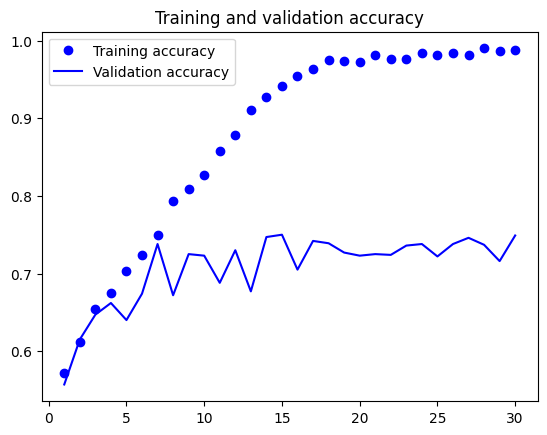

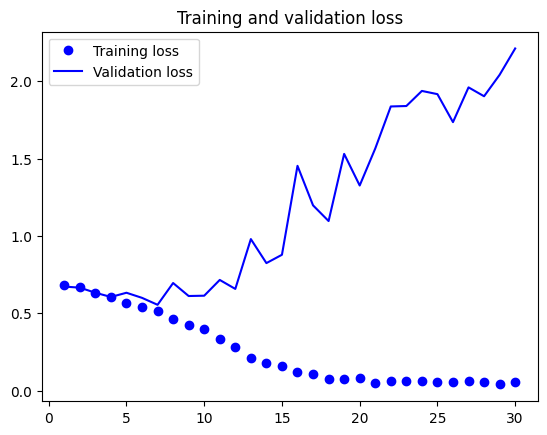

In [78]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [85]:
test_model = keras.models.load_model("convnet_cat_dog.h5")
test_loss, test_acc = test_model.evaluate(test_dataset.take(18))
print(f"Test accuracy: {test_acc:.3f}")

18/18 [==============================] - 8s 414ms/step - loss: 0.5432 - accuracy: 0.7396
Test accuracy: 0.740


<h3> With Augmentation and Dropout to reduce overfitting</h3>

In [87]:
data_augmentation = keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.1), layers.RandomZoom(0.2),])


In [88]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)


model.summary()



Model: "model_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 180, 180, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_11 (Rescaling)    (None, 180, 180, 3)       0         
                                                                 
 conv2d_55 (Conv2D)          (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_44 (MaxPooli  (None, 89, 89, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_56 (Conv2D)          (None, 87, 87, 64)        18496     
                                                          

In [89]:
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [90]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath="convnet_cat_dog_with_augmentation.h5", save_best_only=True, monitor="val_loss")]

history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=callbacks)

Epoch 1/100
63/63 [==============================] - ETA: 0s - loss: 0.7008 - accuracy: 0.5125

c:\Users\amfer\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


63/63 [==============================] - 98s 2s/step - loss: 0.7008 - accuracy: 0.5125 - val_loss: 0.6920 - val_accuracy: 0.5200
Epoch 2/100
63/63 [==============================] - 88s 1s/step - loss: 0.6951 - accuracy: 0.5110 - val_loss: 0.6924 - val_accuracy: 0.5000
Epoch 3/100
21/63 [=========>....................] - ETA: 1:03 - loss: 0.6926 - accuracy: 0.5238

KeyboardInterrupt: 